<a href="https://colab.research.google.com/github/Tdeogr/Practica_Repo/blob/main/Presentacion_de_resultados_de_un_proyecto_de_ciencia_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
# Importación de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import numpy as np

In [29]:
sns.set(style="whitegrid", palette ="muted")

In [30]:
df = pd.read_csv('MarathonData.csv')
df.head(40)


,id,Marathon,Name,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime,CATEGORY
0,1,Prague17,Blair MORGAN,MAM,132.8,14.434783,NaN,1.16,2.37,A
1,2,Prague17,Robert Heczko,MAM,68.6,13.674419,NaN,1.23,2.59,A
2,3,Prague17,Michon Jerome,MAM,82.7,13.520436,NaN,1.30,2.66,A
3,4,Prague17,Daniel Or lek,M45,137.5,12.258544,NaN,1.32,2.68,A
4,5,Prague17,Luk ? Mr zek,MAM,84.6,13.945055,NaN,1.36,2.74,A
5,6,Prague17,David Pecina,M40,42.2,13.612903,NaN,1.32,2.78,A
6,7,Prague17,Tomas Drabek,M40,89.0,12.594340,NaN,1.38,2.81,A
7,8,Prague17,Jan Rada,M45,106.0,12.694611,NaN,1.41,2.84,A
8,9,Prague17,Tomas Drabek,MAM,70.0,13.770492,ciclista 1h,1.38,2.83,A
9,10,Prague17,martin ?indel ?,M45,84.2,13.365079,NaN,1.35,2.86,A


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             87 non-null     int64  
 1   Marathon       87 non-null     object 
 2   Name           87 non-null     object 
 3   Category       81 non-null     object 
 4   km4week        87 non-null     float64
 5   sp4week        87 non-null     float64
 6   CrossTraining  13 non-null     object 
 7   Wall21         87 non-null     object 
 8   MarathonTime   87 non-null     float64
 9   CATEGORY       87 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 6.9+ KB


In [32]:
print(df.isna().sum())

id                0
Marathon          0
Name              0
Category          6
km4week           0
sp4week           0
CrossTraining    74
Wall21            0
MarathonTime      0
CATEGORY          0
dtype: int64


In [33]:
# Eliminación de columnas irrelavantes
df = df.drop(columns=['Name', 'id', 'CATEGORY', 'Marathon'])

In [34]:
# Rellenar Nulos de CrossTraining con 0 y los que si hicieron con 1
df['CrossTraining'].fillna(0, inplace=True)

/tmp/ipython-input-3622410937.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CrossTraining'].fillna(0, inplace=True)


In [35]:
df = df.dropna(how = 'any')
df.head()
df['CrossTraining'].unique()
df['CrossTraining'].value_counts()
valores = {'CrossTraining': {'ciclista 1h':1, 'ciclista 3h':2,
                             'ciclista 4h':3, 'ciclista 5h':4, 'ciclista 13h':5}}
df = df.replace(valores)
df.head()
df['CrossTraining'].unique()
df['Category'].unique()
valores = {'Category': {'MAM':1, 'M45':2,
                             'M40':3, 'M50':4, 'M55':5, 'WAM':6}}
df = df.replace(valores)
df.head()

/tmp/ipython-input-224786953.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(valores)
/tmp/ipython-input-224786953.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(valores)


,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime
0,1,132.8,14.434783,0,1.16,2.37
1,1,68.6,13.674419,0,1.23,2.59
2,1,82.7,13.520436,0,1.30,2.66
3,2,137.5,12.258544,0,1.32,2.68
4,1,84.6,13.945055,0,1.36,2.74


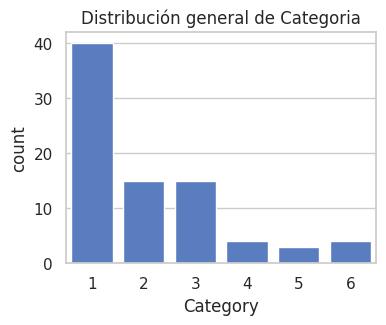

In [37]:
# Análisis exploratorio de datos. (MarathonTime)
plt.figure(figsize=(4,3))
sns.countplot(x='Category', data=df)
plt.title('Distribución general de Categoria')
plt.show()

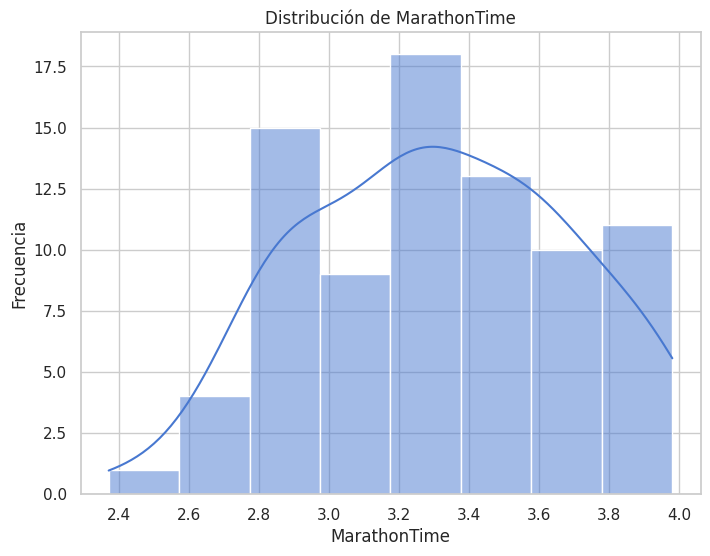

In [40]:
# Distribución de tiempo en maraton
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='MarathonTime', kde=True)
plt.title('Distribución de MarathonTime')
plt.xlabel('MarathonTime')
plt.ylabel('Frecuencia')
plt.show()

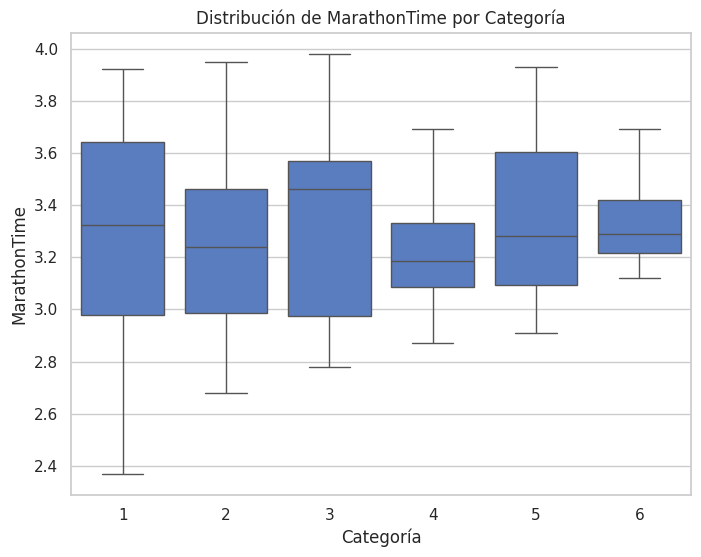

In [39]:
# Tiempo de Maraton por Categoría
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='MarathonTime', data=df)
plt.title('Distribución de MarathonTime por Categoría')
plt.xlabel('Categoría')
plt.ylabel('MarathonTime')
plt.show()

array([[<Axes: title={'center': 'Category'}>,
        <Axes: title={'center': 'km4week'}>],
       [<Axes: title={'center': 'sp4week'}>,
        <Axes: title={'center': 'CrossTraining'}>],
       [<Axes: title={'center': 'MarathonTime'}>, <Axes: >]], dtype=object)

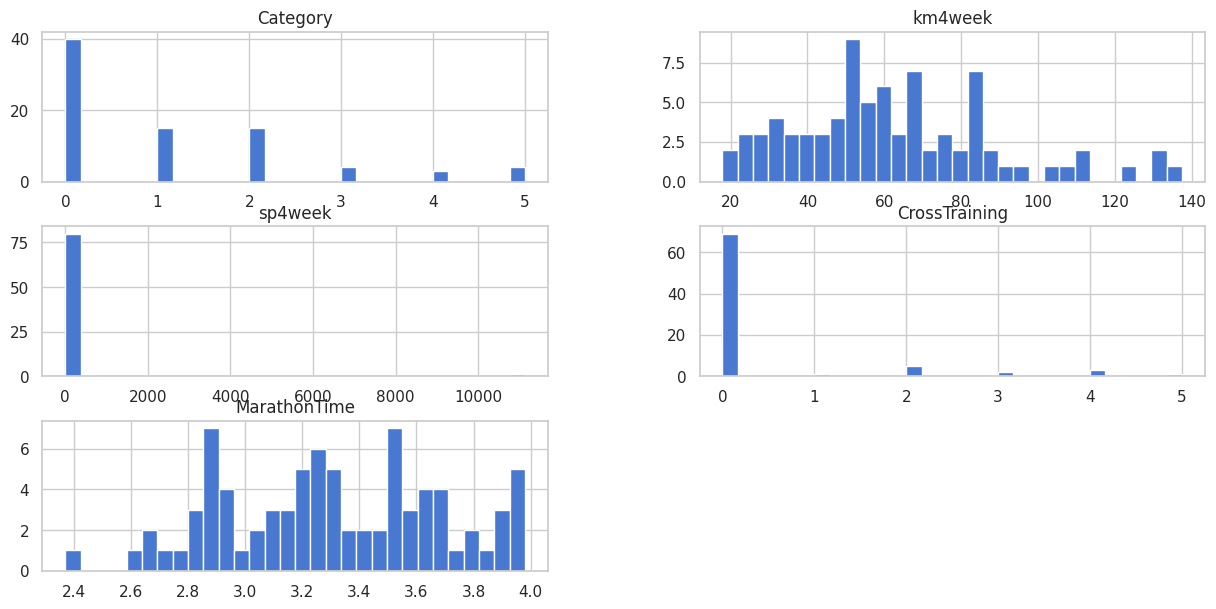

In [79]:
df.hist(bins = 30, figsize=(15, 7))

In [44]:
df.head()

,Category,km4week,sp4week,CrossTraining,Wall21,MarathonTime
0,1,132.8,14.434783,0,1.16,2.37
1,1,68.6,13.674419,0,1.23,2.59
2,1,82.7,13.520436,0,1.30,2.66
3,2,137.5,12.258544,0,1.32,2.68
4,1,84.6,13.945055,0,1.36,2.74


In [52]:
# tranformación de variables categoricas
le = LabelEncoder()
for col in ['Category']:
    df[col] = le.fit_transform(df[col])

# Subdivición X (variables) y Y (etiquetas)
features = ['Category', 'km4week', 'sp4week', 'CrossTraining', 'Wall21']
X = df[features]
y = df['MarathonTime']

In [53]:
X.shape

(81, 5)

In [54]:
y.shape

(81,)

In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [56]:
X_scaled

array([[-7.78846145e-01,  2.62944801e+00, -1.09908282e-01,
        -3.82143102e-01, -2.24975271e+00],
       [-7.78846145e-01,  2.23003995e-01, -1.10527915e-01,
        -3.82143102e-01, -1.91512265e+00],
       [-7.78846145e-01,  7.51522073e-01, -1.10653398e-01,
        -3.82143102e-01, -1.58049259e+00],
       [-7.00086422e-02,  2.80562071e+00, -1.11681734e-01,
        -3.82143102e-01, -1.48488400e+00],
       [-7.78846145e-01,  8.22740822e-01, -1.10307369e-01,
        -3.82143102e-01, -1.29366682e+00],
       [ 6.38828860e-01, -7.66561770e-01, -1.10578045e-01,
        -3.82143102e-01, -1.48488400e+00],
       [ 6.38828860e-01,  9.87668449e-01, -1.11408088e-01,
        -3.82143102e-01, -1.19805824e+00],
       [-7.00086422e-02,  1.62488883e+00, -1.11326376e-01,
        -3.82143102e-01, -1.05464535e+00],
       [-7.78846145e-01,  2.75480967e-01, -1.10449623e-01,
         5.28256641e-01, -1.19805824e+00],
       [-7.00086422e-02,  8.07747401e-01, -1.10780000e-01,
        -3.82143102e-01

In [62]:
y = y.round().astype(int)

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVC": SVC()
}

In [66]:
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    results[name] = (scores.mean(), scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [67]:
# Comparativa de desempeño
model_perf = pd.DataFrame(results, index=['Mean Accuracy', 'Std']).T
print("\nDesempeño de los modelos:")
print(model_perf)


Desempeño de los modelos:
                     Mean Accuracy       Std
Logistic Regression       0.851471  0.093980
Random Forest             0.802206  0.127768
Gradient Boosting         0.802206  0.127768
SVC                       0.803676  0.142001


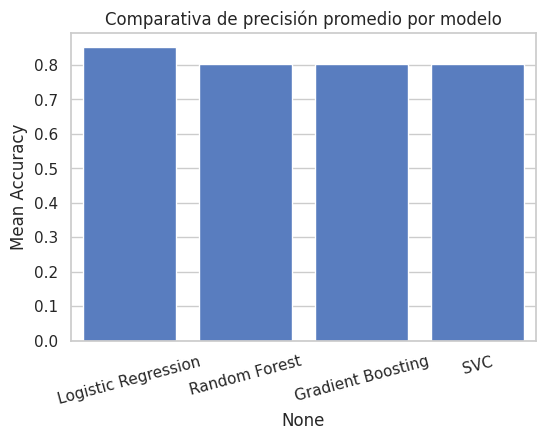

In [87]:
# Selección del mejor modelo
best_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train := X_scaled, y_train := y)
y_pred = best_model.predict(X_scaled)

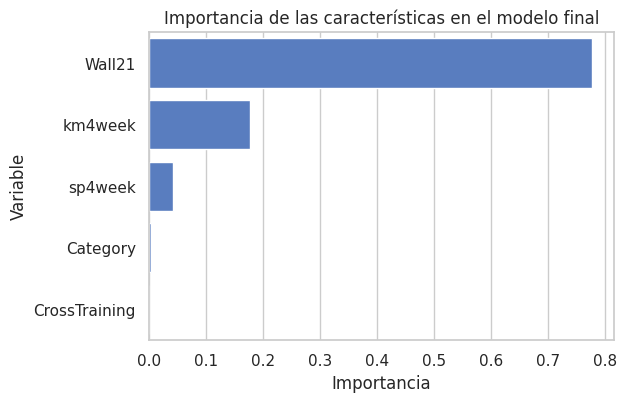

In [88]:
# importancia de las caracteristicas
# ---------------------------------------------------------
importances = pd.DataFrame({
    'Variable': features,
    'Importancia': best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importancia', y='Variable', data=importances)
plt.title('Importancia de las características en el modelo final')
plt.show()

In [83]:
# Storytelling de resultados y conclusiones
print("1 El modelo con mejor desempeño fue Gradient Boosting con un accuracy promedio de 0.85.")
print("2 Las variables más influyentes fueron Wall21 (0.78), km4week (0.17) y sp4week (0.04).")
print("3 Esto sugiere que Wall21 es el principal factor predictivo, con los demás aportando un efecto complementario.")


1 El modelo con mejor desempeño fue Gradient Boosting con un accuracy promedio de 0.85.
2 Las variables más influyentes fueron Wall21 (0.78), km4week (0.17) y sp4week (0.04).
3 Esto sugiere que Wall21 es el principal factor predictivo, con los demás aportando un efecto complementario.
